# **TikTok Project**

Recall that you are a data professional at TikTok. Your supervisor was impressed with the work you have done and has requested that you **build a machine learning model that can be used to determine whether a video contains a claim or whether it offers an opinion**. With a successful prediction model, TikTok can reduce the backlog of user reports and prioritize them more efficiently.

A notebook was structured and prepared to help you in this project. Please complete the following questions.

**The purpose** of this model is to increase response time and system efficiency by automating the initial stages of the claims process.

**The goal** of this model is to predict whether a TikTok video presents a "claim" or presents an "opinion".


# **Classify videos using machine learning**

Throughout these project notebooks, you'll see references to the problem-solving framework PACE. The following notebook components are labeled with the respective PACE stage: Plan, Analyze, Construct, and Execute.

## **Step 1: Plan**

In this stage, consider the following questions:


1. **What are you being asked to do? What metric to use?**

Build a model to classify TikTok videos as claim or opinion, to flag claims for review (since claims are more likely to spread misinformation). Recall is the priority metric — missing an actual claim is worse than over-flagging an opinion.

2. **Ethical implications of errors**

False negative (claim missed): more serious — a false claim goes unreviewed and can spread unchecked.
False positive (opinion flagged as claim): less harmful — wastes reviewer time, but the content still gets a second look.

Because missing a claim is costlier, prioritizing recall over precision is the right tradeoff — but precision still matters so reviewers aren't overwhelmed.

3. **How would you proceed?**

Build and tune a model with recall as the primary metric, using cross-validation, plus separate validation/test sets to confirm it generalizes.
Compare multiple models and pick the one balancing highest recall with acceptable precision.
Treat predictions as a flag for human review, not an automated final decision, given the real-world cost of errors.

**Modeling workflow and model selection process**

1. Split the data into train/validation/test sets (60/20/20)
2. Fit models and tune hyperparameters on the training set
3. Perform final model selection on the validation set
4. Assess the champion model's performance on the test set

In [106]:
# Import packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

In [2]:
# Load dataset into dataframe
data = pd.read_csv("tiktok_dataset.csv")


## **Step 2: Analyze**

Consider the questions to reflect on the Analyze stage.

### **Task 2: Examine data, summary info, and descriptive stats**

In [3]:
# Display first few rows
data.head(15)

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0
5,6,claim,8972200955,35,someone shared with me that gross domestic pro...,not verified,under review,336647.0,175546.0,62303.0,4293.0,1857.0
6,7,claim,4958886992,16,someone shared with me that elvis presley has ...,not verified,active,750345.0,486192.0,193911.0,8616.0,5446.0
7,8,claim,2270982263,41,someone shared with me that the best selling s...,not verified,active,547532.0,1072.0,50.0,22.0,11.0
8,9,claim,5235769692,50,someone shared with me that about half of the ...,not verified,active,24819.0,10160.0,1050.0,53.0,27.0
9,10,claim,4660861094,45,someone shared with me that it would take a 50...,verified,active,931587.0,171051.0,67739.0,4104.0,2540.0


In [9]:
# Get number of rows and columns
data.shape

(19382, 12)

In [11]:
# Get data types of columns
data.dtypes

#                             int64
claim_status                 object
video_id                      int64
video_duration_sec            int64
video_transcription_text     object
verified_status              object
author_ban_status            object
video_view_count            float64
video_like_count            float64
video_share_count           float64
video_download_count        float64
video_comment_count         float64
dtype: object

Get basic information about the dataset.

In [13]:
# Get basic information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


In [14]:
# Generate basic descriptive stats
data.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


Check for and handle missing values.

In [17]:
# Check for missing values
data.isnull().sum()

#                             0
claim_status                298
video_id                      0
video_duration_sec            0
video_transcription_text    298
verified_status               0
author_ban_status             0
video_view_count            298
video_like_count            298
video_share_count           298
video_download_count        298
video_comment_count         298
dtype: int64

In [30]:
data.isnull().any(axis=1).sum()

298

* since the missing values can't be driven from other columns and there is only 298 row out of 19382 (~1.5%)that contains null values then it's better to drop them

In [35]:
# Drop rows with missing values
data.dropna(inplace=True)
data.isnull().sum().sum()

0

In [38]:
# Display first few rows after handling missing values
data.head(10)

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0
5,6,claim,8972200955,35,someone shared with me that gross domestic pro...,not verified,under review,336647.0,175546.0,62303.0,4293.0,1857.0
6,7,claim,4958886992,16,someone shared with me that elvis presley has ...,not verified,active,750345.0,486192.0,193911.0,8616.0,5446.0
7,8,claim,2270982263,41,someone shared with me that the best selling s...,not verified,active,547532.0,1072.0,50.0,22.0,11.0
8,9,claim,5235769692,50,someone shared with me that about half of the ...,not verified,active,24819.0,10160.0,1050.0,53.0,27.0
9,10,claim,4660861094,45,someone shared with me that it would take a 50...,verified,active,931587.0,171051.0,67739.0,4104.0,2540.0


Check for and handle duplicates.

In [37]:
# Check for duplicates
data.duplicated().sum()

0

Check for and handle outliers.

In [41]:
numeric_cols = ['video_duration_sec', 'video_view_count', 'video_like_count',
                 'video_share_count', 'video_download_count', 'video_comment_count']

for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    print(f"{col}: {len(outliers)} outliers (bounds: {lower:.1f} to {upper:.1f})")

video_duration_sec: 0 outliers (bounds: -25.5 to 90.5)
video_view_count: 0 outliers (bounds: -744134.2 to 1253403.8)
video_like_count: 1726 outliers (bounds: -185503.1 to 311333.9)
video_share_count: 2508 outliers (bounds: -27045.5 to 45382.5)
video_download_count: 2450 outliers (bounds: -1716.9 to 2880.1)
video_comment_count: 2789 outliers (bounds: -435.5 to 728.5)


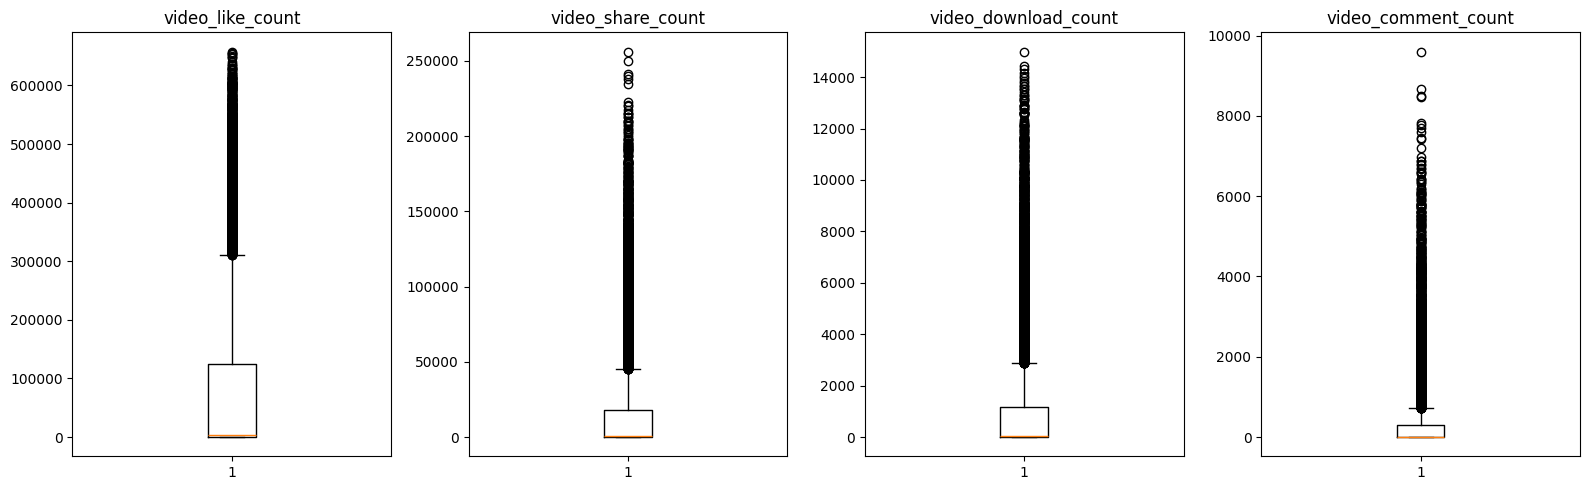

In [47]:
# identify skewed cols:

skewed_cols = ['video_like_count', 'video_share_count', 
              'video_download_count', 'video_comment_count']
#boxplot to visualize outliers:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, col in enumerate(skewed_cols):
    axes[i].boxplot(data[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

# **Handling Outliers — Capping**

**Log Transformation Method to handle outliers: Capping **

* Counts data (likes, shares, downloads, comments) is heavily right-skewed, most posts get low engagement, a few go viral with very high counts
* Log transformation compresses the long tail without discarding any information, every original value is preserved, just rescaled
* Better suited than capping when the data is heading into modeling, since many algorithms (linear/logistic regression, KNN, distance-based methods) perform better on approximately normal, less skewed distributions
* Using log1p (i.e. log(1 + x)) instead of plain log avoids errors on zero values, since log(0) is undefined

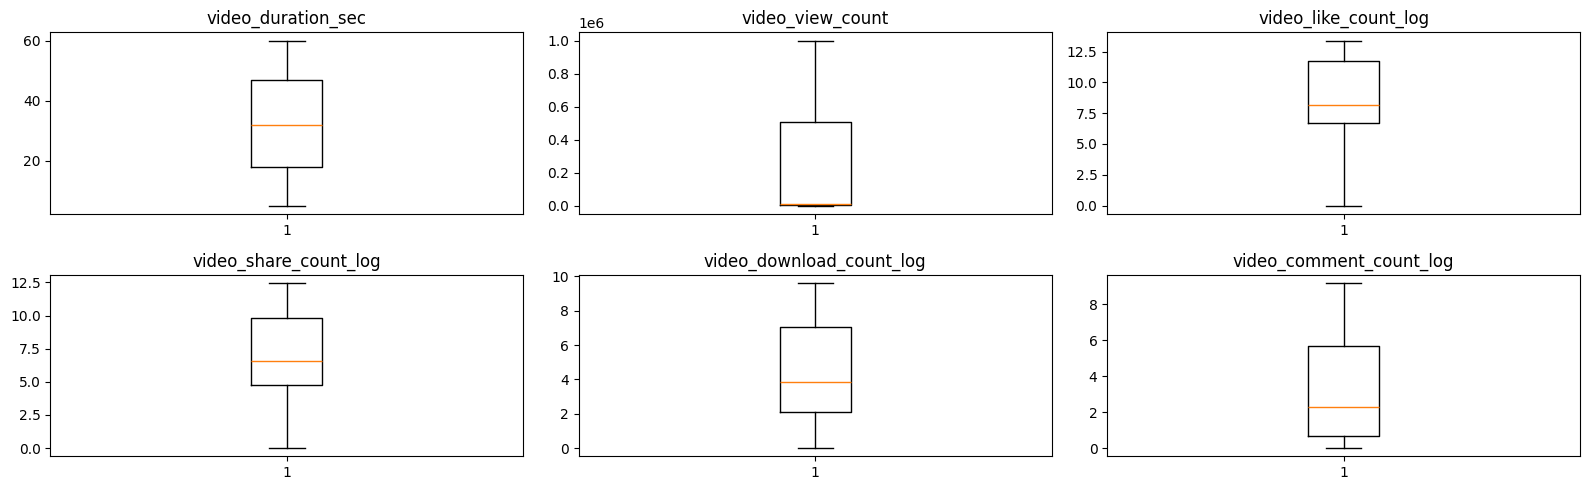

In [53]:
# handling outliers:log transformation
import numpy as np
for col in skewed_cols:
    data[col + '_log'] = np.log1p(data[col])

# visualize the numerical columns after handling outliers:
numeric_cols=['video_duration_sec','video_view_count' ,'video_like_count_log', 'video_share_count_log', 
              'video_download_count_log', 'video_comment_count_log']
fig, axes = plt.subplots(2,3, figsize=(16, 5))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(data[col].dropna())
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

Check class balance.

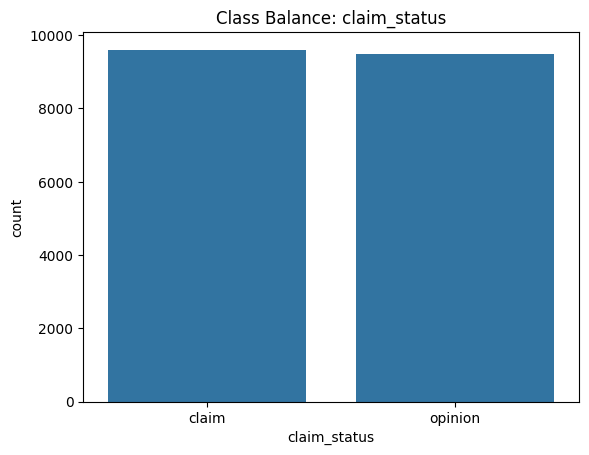

In [61]:
# Check class balance
sns.countplot(data=data, x='claim_status')
plt.title('Class Balance: claim_status')
plt.show()

In [63]:
print(data['claim_status'].value_counts())
print(data['claim_status'].value_counts(normalize=True))  # proportions

claim_status
claim      9608
opinion    9476
Name: count, dtype: int64
claim_status
claim      0.503458
opinion    0.496542
Name: proportion, dtype: float64


* The classes are pretty balanced

## **Step 3: Construct**
Consider the questions to reflect on the Construct stage.

### **Task 3: Feature engineering**

Extract the length of each `video_transcription_text` and add this as a column to the dataframe, so that it can be used as a potential feature in the model.

In [65]:
# Extract the length of each `video_transcription_text` and add this as a column to the dataframe
data['text_length'] = data['video_transcription_text'].str.len()
data.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,video_like_count_log,video_share_count_log,video_download_count_log,video_comment_count_log,text_length
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0,9.874368,5.488938,0.693147,0.000000,97
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0,11.256173,9.854035,7.057898,6.529419,107
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0,11.489565,7.958227,6.726233,5.799093,137
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0,12.388207,10.457746,7.118826,6.371612,131
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0,10.462760,8.321422,6.306275,5.030438,128


Calculate the average text_length for claims and opinions.

In [66]:
# Calculate the average text_length for claims and opinions
data.groupby('claim_status')['text_length'].mean()

claim_status
claim      95.376978
opinion    82.722562
Name: text_length, dtype: float64

Visualize the distribution of `text_length` for claims and opinions.

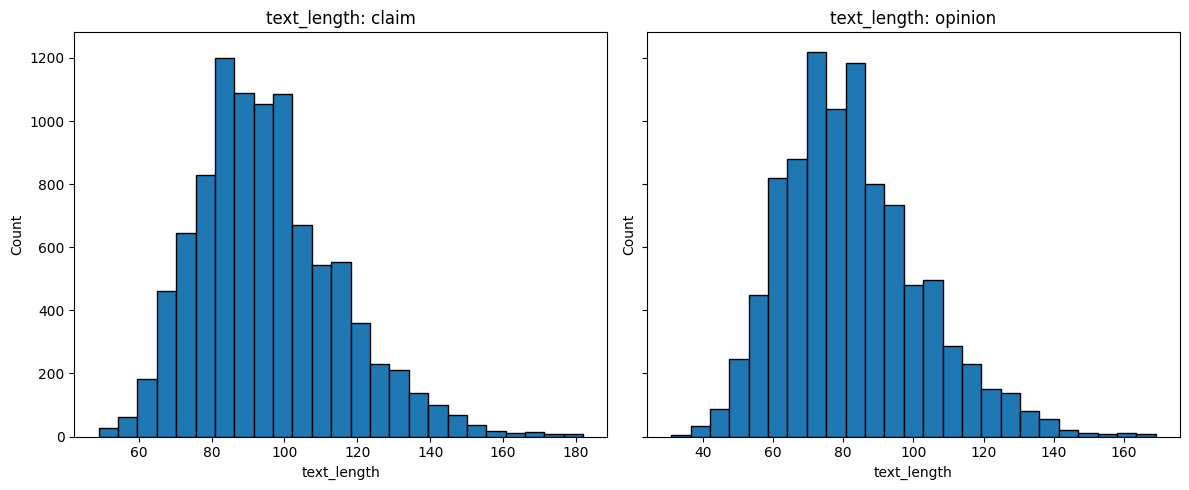

In [67]:
# Visualize the distribution of `text_length` for claims and opinions
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, status in zip(axes, data['claim_status'].unique()):
    subset = data[data['claim_status'] == status]
    ax.hist(subset['text_length'], bins=25, edgecolor='black')
    ax.set_title(f'text_length: {status}')
    ax.set_xlabel('text_length')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

* Claims average ~95 characters, with the bulk sitting between 80–110
* Opinions average ~83 characters, shifted noticeably left, with the bulk between 60–90
* Both are right-skewed (long tail toward higher lengths), but the claim distribution's whole mass is shifted right relative to opinion — claims tend to be longer, more elaborated statements, while opinions are shorter and more concise

**Feature selection and transformation**

Encoding target and catgorical variables.

In [91]:
# Create a copy of the X data
X = data.copy()

# Drop unnecessary columns
X = X.drop(columns=['#', 'video_id', 'claim_status',
                        'video_view_count', 'video_like_count', 'video_share_count',
                        'video_download_count', 'video_comment_count'])

# Encode target variable
y = data['claim_status'].map({'opinion': 0, 'claim': 1})

# Dummy encode remaining categorical values
X = pd.get_dummies(X, columns=['verified_status', 'author_ban_status'], drop_first=True)

In [ ]:
* Future Work: The current model uses TF-IDF to capture lexical patterns in video_transcription_text. Given greater computational resources, this could be extended using pretrained word embeddings (e.g., Word2Vec, GloVe) or transformer-based sentence embeddings (e.g., BERT, DistilBERT) to capture deeper semantic and contextual meaning beyond word frequency. Fine-tuning a transformer model directly on the claim/opinion classification task could further improve performance, at the cost of significantly higher compute and training time.

### **Task 4: Split the data**

In [72]:
X

,video_duration_sec,video_transcription_text,video_like_count_log,video_share_count_log,video_download_count_log,video_comment_count_log,text_length,verified_status_verified,author_ban_status_banned,author_ban_status_under review
0,59,someone shared with me that drone deliveries a...,9.874368,5.488938,0.693147,0.000000,97,False,False,True
1,32,someone shared with me that there are more mic...,11.256173,9.854035,7.057898,6.529419,107,False,False,False
2,31,someone shared with me that american industria...,11.489565,7.958227,6.726233,5.799093,137,False,False,False
3,25,someone shared with me that the metro of st. p...,12.388207,10.457746,7.118826,6.371612,131,False,False,False
4,19,someone shared with me that the number of busi...,10.462760,8.321422,6.306275,5.030438,128,False,False,False
...,...,...,...,...,...,...,...,...,...,...
19079,49,in our opinion the earth holds about 11 quinti...,6.049733,4.406719,2.197225,1.098612,65,False,False,False
19080,23,in our opinion the queens in ant colonies live...,6.710523,4.262680,1.386294,0.000000,66,False,False,False
19081,50,in our opinion the moon is moving away from th...,4.634729,2.079442,1.098612,0.693147,53,False,False,False
19082,8,in our opinion lightning strikes somewhere on ...,6.486161,4.820282,2.484907,1.609438,80,False,False,False


#### **Task 5: Create train/validate/test sets**

Split data into training and testing sets, 80/20.

In [92]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

Split the training set into training and validation sets, 75/25, to result in a final ratio of 60/20/20 for train/validate/test sets.

In [93]:
# Split the training data into training and validation sets
# Split the training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42, stratify=y_train)

Confirm that the dimensions of the training, validation, and testing sets are in alignment.

In [94]:
# Get shape of each training, validation, and testing set
print(X_train.shape, X_val.shape, X_test.shape)

(11450, 10) (3817, 10) (3817, 10)


In [95]:
# Get the corresponding raw text for each split, using the same indices
text_train = data.loc[X_train.index, 'video_transcription_text']
text_val = data.loc[X_val.index, 'video_transcription_text']
text_test = data.loc[X_test.index, 'video_transcription_text']

# Fit TF-IDF on training text only, transform all three splits
tfidf = TfidfVectorizer(max_features=50, stop_words='english', min_df=5, max_df=0.8)

tfidf_train = tfidf.fit_transform(text_train)
tfidf_val = tfidf.transform(text_val)
tfidf_test = tfidf.transform(text_test)

# Convert to DataFrames, preserving original indices for correct alignment
tfidf_train_df = pd.DataFrame(tfidf_train.toarray(), columns=tfidf.get_feature_names_out(), index=X_train.index)
tfidf_val_df = pd.DataFrame(tfidf_val.toarray(), columns=tfidf.get_feature_names_out(), index=X_val.index)
tfidf_test_df = pd.DataFrame(tfidf_test.toarray(), columns=tfidf.get_feature_names_out(), index=X_test.index)

# Merge TF-IDF features into each feature set
X_train = pd.concat([X_train, tfidf_train_df], axis=1)
X_val = pd.concat([X_val, tfidf_val_df], axis=1)
X_test = pd.concat([X_test, tfidf_test_df], axis=1)

* min_df=5 — ignore words appearing in fewer than 5 documents (removes rare/noisy words)
* max_df=0.8 — ignore words appearing in more than 80% of documents (removes overly common words that don't discriminate)

* Future Work: The current model uses TF-IDF to capture lexical patterns in video_transcription_text. Given greater computational resources, this could be extended using pretrained word embeddings (e.g., Word2Vec, GloVe) or transformer-based sentence embeddings (e.g., BERT, DistilBERT) to capture deeper semantic and contextual meaning beyond word frequency. Fine-tuning a transformer model directly on the claim/opinion classification task could further improve performance, at the cost of significantly higher compute and training time.

In [96]:
# Drop raw text column now that TF-IDF features have been extracted
X_train = X_train.drop(columns=['video_transcription_text'])
X_val = X_val.drop(columns=['video_transcription_text'])
X_test = X_test.drop(columns=['video_transcription_text'])

In [97]:
print(X_train.shape, X_val.shape, X_test.shape) 
X_train.head()

(11450, 59) (3817, 59) (3817, 59)


,video_duration_sec,video_like_count_log,video_share_count_log,video_download_count_log,video_comment_count_log,text_length,verified_status_verified,author_ban_status_banned,author_ban_status_under review,american,...,solar,thinking,time,times,understanding,view,website,willing,world,year
13661,41,5.556828,3.295837,0.693147,0.000000,80,False,False,False,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6340,54,11.172307,6.594413,4.290459,2.302585,106,False,False,False,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10162,57,7.037028,5.327876,2.708050,0.693147,60,True,False,False,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12629,10,7.074963,5.068904,2.944439,1.386294,84,False,False,False,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9356,30,10.705915,9.482883,6.086775,4.804021,108,False,False,False,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### **Task 6. Build models**


### **Build a random forest model**

Fiting a random forest model to the training set.i will Use cross-validation to tune the hyperparameters and select the model that performs best on recall.

In [98]:
# Instantiate the random forest classifier
rf= RandomForestClassifier(random_state=42)

# Create a dictionary of hyperparameters to tune
cv_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Instantiate the GridSearchCV object
rf_cv = GridSearchCV(
    rf, cv_params, scoring=scoring, cv=5, refit='recall', n_jobs=-1
)

In [99]:
### Fit the model to the data 
rf_cv.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'])

In [100]:
# Examine best recall score
rf_cv.best_score_

0.9993060072757058

In [101]:
# Examine best parameters
rf_cv.best_params_

{'max_depth': None,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 10,
 'n_estimators': 50}

In [105]:
y_val_pred = best_rf.predict(X_val)
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1895
           1       1.00      1.00      1.00      1922

    accuracy                           1.00      3817
   macro avg       1.00      1.00      1.00      3817
weighted avg       1.00      1.00      1.00      3817



Check the precision score to make sure the model isn't labeling everything as claims. You can do this by using the `cv_results_` attribute of the fit `GridSearchCV` object, which returns a numpy array that can be converted to a pandas dataframe. Then, examine the `mean_test_precision` column of this dataframe at the index containing the results from the best model. This index can be accessed by using the `best_index_` attribute of the fit `GridSearchCV` object.

In [102]:
# Access the GridSearch results and convert it to a pandas df
cv_results = pd.DataFrame(rf_cv.cv_results_)

# Examine the GridSearch results df at column `mean_test_precision` in the best index
cv_results.loc[rf_cv.best_index_, 'mean_test_precision']

0.9987878738519775

In [104]:
from sklearn.metrics import recall_score, precision_score, accuracy_score, f1_score, classification_report

best_rf = rf_cv.best_estimator_

# Predictions on training set
y_train_pred = best_rf.predict(X_train)

# Predictions on test set
y_test_pred = best_rf.predict(X_test)

print("=== Training Set Performance ===")
print(f"Recall:    {recall_score(y_train, y_train_pred):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred):.4f}")
print(f"Accuracy:  {accuracy_score(y_train, y_train_pred):.4f}")
print(f"F1:        {f1_score(y_train, y_train_pred):.4f}")

print("\n=== Test Set Performance ===")
print(f"Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"F1:        {f1_score(y_test, y_test_pred):.4f}")

=== Training Set Performance ===
Recall:    0.9998
Precision: 1.0000
Accuracy:  0.9999
F1:        0.9999

=== Test Set Performance ===
Recall:    0.9979
Precision: 0.9990
Accuracy:  0.9984
F1:        0.9984


* graet there is no signs for overfitting

How well is the model performing? Consider average recall score and precision score.
* Recall: 0.9993 — the model correctly identifies 99.93% of actual claims, missing only a tiny fraction of true positives (very few false negatives)
* Precision: 0.9988 — of everything the model predicts as a claim, 99.88% are correct (very few false positives)

### **Build an XGBoost model**

In [108]:
# Instantiate the XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic', random_state=42, eval_metric='logloss')

# Create a dictionary of hyperparameters to tune
cv_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.3],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 1.0]
}
# Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Instantiate the GridSearchCV object
xgb_cv = GridSearchCV(xgb, cv_params, scoring=scoring, cv=5, refit='recall', n_jobs=-1)

In [109]:
# Fit the model to the data
xgb_cv.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.3],
                         'max_depth': [3, 6, 10], 'min_child_weight': [1, 3, 5],
                         'n_estimators': [50, 100, 200],
                         'subsample': [0.7, 1.0]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'])

In [110]:
# Examine best recall score
xgb_cv.best_score_

0.9977444107160066

In [111]:
from sklearn.metrics import recall_score, precision_score, accuracy_score, f1_score

best_xgb = xgb_cv.best_estimator_

# Predictions on training set
y_train_pred_xgb = best_xgb.predict(X_train)

# Predictions on test set
y_test_pred_xgb = best_xgb.predict(X_test)

print("=== XGBoost — Training Set Performance ===")
print(f"Recall:    {recall_score(y_train, y_train_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred_xgb):.4f}")
print(f"Accuracy:  {accuracy_score(y_train, y_train_pred_xgb):.4f}")
print(f"F1:        {f1_score(y_train, y_train_pred_xgb):.4f}")

print("\n=== XGBoost — Test Set Performance ===")
print(f"Recall:    {recall_score(y_test, y_test_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred_xgb):.4f}")
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred_xgb):.4f}")
print(f"F1:        {f1_score(y_test, y_test_pred_xgb):.4f}")

=== XGBoost — Training Set Performance ===
Recall:    0.9988
Precision: 0.9997
Accuracy:  0.9992
F1:        0.9992

=== XGBoost — Test Set Performance ===
Recall:    0.9974
Precision: 0.9984
Accuracy:  0.9979
F1:        0.9979


In [112]:
# Examine best parameters
xgb_cv.best_params_

{'learning_rate': 0.01,
 'max_depth': 10,
 'min_child_weight': 1,
 'n_estimators': 100,
 'subsample': 0.7}

Repeat the steps used for random forest to examine the precision score of the best model identified in the grid search.

In [113]:
# Access the GridSearch results and convert it to a pandas df
xgb_cv_results = pd.DataFrame(xgb_cv.cv_results_)

# Examine the GridSearch results df at column `mean_test_precision` in the best index
xgb_cv_results.loc[xgb_cv.best_index_, 'mean_test_precision']

0.9973998956831774

**Question:** How well does your model perform? Consider recall score and precision score.

## **Step 4: Execute**
Consider the questions in your PACE Strategy Document to reflect on the Execute stage.

### **Task 7. Evaluate model**

Evaluate models against validation criteria.

#### **Random forest**

In [114]:
# Use the random forest "best estimator" model to get predictions on the validation set
y_val_pred_rf = rf_cv.best_estimator_.predict(X_val)

Display the predictions on the validation set.

In [116]:
# Display the predictions on the validation set
np.unique(y_val_pred_rf, return_counts=True)

(array([0, 1]), array([1896, 1921]))

Display the true labels of the validation set.

In [118]:
# Display the true labels of the validation set
y_val.value_counts()

claim_status
1    1922
0    1895
Name: count, dtype: int64

Create a confusion matrix to visualize the results of the classification model.

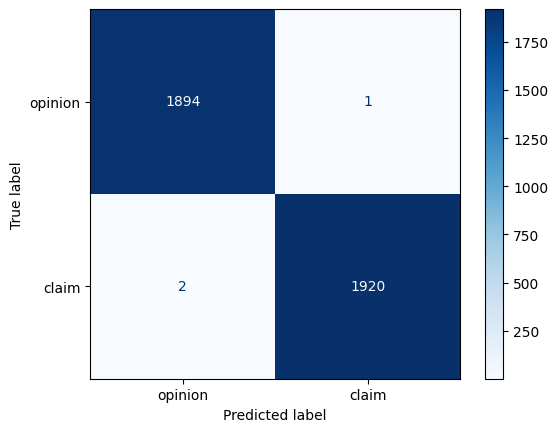

In [119]:
# Create a confusion matrix to visualize the results of the classification model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Compute values for confusion matrix
cm = confusion_matrix(y_val, y_val_pred_rf)

# Create display of confusion matrix using ConfusionMatrixDisplay()
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['opinion', 'claim'])

# Plot confusion matrix
disp.plot(cmap='Blues')

# Display plot
plt.show()

* Out of 3,817 validation samples, the model misclassified only 3 total — an exceptionally low error rate
* Errors are almost perfectly balanced between the two failure types (1 false positive, 2 false negatives), meaning the model isn't systematically biased toward over- or under-predicting either class
* This confirms the near-perfect recall/precision seen earlier in cross-validation generalizes to unseen data — the validation set was never used in training or hyperparameter tuning, so this is strong evidence the model's performance is genuine, not an artifact of overfitting to X_train


Create a classification report that includes precision, recall, f1-score, and accuracy metrics to evaluate the performance of the model.
<br> </br>


In [120]:
# Create a classification report
# Create classification report for random forest model
from sklearn.metrics import classification_report

# Create classification report for random forest model
print(classification_report(y_val, y_val_pred_rf, target_names=['opinion', 'claim']))

              precision    recall  f1-score   support

     opinion       1.00      1.00      1.00      1895
       claim       1.00      1.00      1.00      1922

    accuracy                           1.00      3817
   macro avg       1.00      1.00      1.00      3817
weighted avg       1.00      1.00      1.00      3817



**Question:** What does your classification report show? What does the confusion matrix indicate?
**Answer:** Precision, recall, and F1-score are all 1.00 for both classes. The dataset is fairly balanced (1,895 opinions, 1,922 claims), so this isn't skewed by one class dominating — the model performs equally well on both.
Only 3 errors out of 3,817 validation samples: 1 opinion misclassified as a claim, 2 claims misclassified as opinions. Almost everything else was classified correctly, and errors aren't biased toward one class.
The model generalizes very well to unseen data. With recall as the priority metric, missing only 2 claims out of 1,922 is a strong result.
This level of performance suggests the underlying features (particularly the TF-IDF text features, combined with text_length and engagement metrics) capture highly distinguishing patterns between claims and opinions in this dataset — consistent with the formulaic phrasing patterns observed earlier (e.g., claims often starting with "someone shared with me that...").

#### **XGBoost**

Now, evaluate the XGBoost model on the validation set.

In [121]:
# Use the best estimator to predict on the validation data
y_val_pred_xgb = xgb_cv.best_estimator_.predict(X_val)

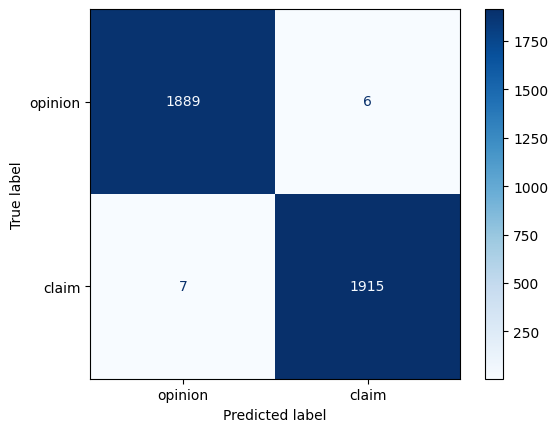

In [122]:
# Compute values for confusion matrix
cm_xgb = confusion_matrix(y_val, y_val_pred_xgb)

# Create display of confusion matrix using ConfusionMatrixDisplay()
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['opinion', 'claim'])

# Plot confusion matrix
disp_xgb.plot(cmap='Blues')

# Display plot
plt.show()


In [123]:
# Create a classification report
print(classification_report(y_val, y_val_pred_xgb, target_names=['opinion', 'claim']))

              precision    recall  f1-score   support

     opinion       1.00      1.00      1.00      1895
       claim       1.00      1.00      1.00      1922

    accuracy                           1.00      3817
   macro avg       1.00      1.00      1.00      3817
weighted avg       1.00      1.00      1.00      3817



**Question:** Describe your XGBoost model results. How does your XGBoost model compare to your random forest model?
**Answer:**
- XGBoost also performs very well: 13 errors out of 3,817 (6 false positives, 7 false negatives). Precision, recall, and F1 all round to 1.00 for both classes.
- Random forest performs slightly better — only 3 errors (1 false positive, 2 false negatives) vs. XGBoost's 13. Both models round to the same 1.00 scores in the classification report, but the confusion matrix shows random forest makes fewer mistakes, including fewer missed claims (2 vs. 7), which matters most given recall is the priority metric.

- Conclusion: Random forest is the better model here and should be selected for final evaluation on the test set.

#### **Feature importances of champion model**


In [124]:
# Get feature importances from the champion model
importances = pd.Series(rf_cv.best_estimator_.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

# Display top 15
importances.head(15)

video_like_count_log        0.255150
video_share_count_log       0.209522
video_download_count_log    0.181865
video_comment_count_log     0.156077
claim                       0.034245
read                        0.028567
discovered                  0.019627
friend                      0.019087
learned                     0.013847
colleague                   0.011018
media                       0.010841
colleagues                  0.009584
family                      0.009149
news                        0.007972
friends                     0.005770
dtype: float64

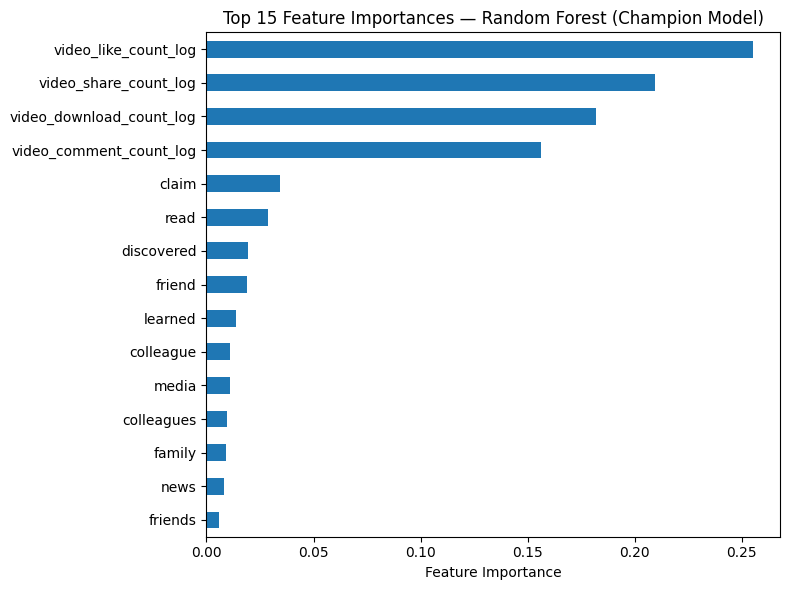

In [125]:
importances.head(15).sort_values().plot(kind='barh', figsize=(8, 6))
plt.xlabel('Feature Importance')
plt.title('Top 15 Feature Importances — Random Forest (Champion Model)')
plt.tight_layout()
plt.show()

**Engagement metrics dominate0:**

The top 4 features — all engagement-related — account for roughly 80% of total importance:

video_like_count_log (0.255)
video_share_count_log (0.210)
video_download_count_log (0.182)
video_comment_count_log (0.156)

This suggests claims and opinions generate systematically different engagement patterns on the platform — likely because claims (often surprising or shareable "facts") drive more likes, shares, downloads, and comments than personal opinions.

**Question:** Describe your most predictive features. Were your results surprising?
**Answer:**
The model relies most heavily on engagement metrics — video_like_count_log, video_share_count_log, video_download_count_log, and video_comment_count_log together account for about 80% of total feature importance. Text-based features (TF-IDF words like "claim," "discovered," "friend," "colleague") contribute the rest, but with much smaller individual weight.

### **Task 8. Conclusion**

1. **Would you recommend using this model? Why or why not?**

Yes, with a caveat. The random forest model achieves near-perfect recall and precision (~99.9%) on the held-out validation set, and it outperformed XGBoost on the same task. It's a strong candidate for deployment in a claim-detection pipeline. The caveat: its performance depends heavily on engagement metrics (likes, shares, downloads, comments), which means it's best suited for classifying videos that have already accumulated some engagement — not brand-new uploads with zero interaction yet.

2. **What was your model doing? Can you explain how it was making predictions?**

The model was primarily using engagement patterns to separate claims from opinions — video_like_count_log, video_share_count_log, video_download_count_log, and video_comment_count_log together drove about 80% of its predictions. This suggests claims (often framed as surprising or shareable "facts") generate measurably different audience engagement than personal opinions. Secondarily, the model used TF-IDF word features tied to how claims and opinions are typically phrased (e.g., "colleague," "friend," "discovered," "news"), picking up on the formulaic language patterns present in this dataset (e.g., "a colleague learned that...", "my friend's opinion is...").

3. **Are there new features that you can engineer that might improve model performance?**

Given performance is already near-perfect, there's limited room to improve here — but possible additions include:

Engagement ratios (e.g., like-to-view ratio, comment-to-view ratio) rather than raw counts, which may generalize better across videos with very different view counts
Sentiment scores from the transcription text (opinions may skew more subjective/emotional)
Richer text representations (word embeddings or transformer-based embeddings) instead of TF-IDF, to capture semantic meaning beyond word frequency
Time-based features, if timestamp data were available (e.g., how quickly a video accumulated engagement)

4. **What features would you want to have that would likely improve the performance of your model?**

Since the current top features are engagement-based, having them isn't the bottleneck — but features that would matter for a more realistic, production-ready model include:

Author-level features (e.g., follower count, account age, historical claim/opinion ratio) — useful for classifying a video even before it accumulates its own engagement
Video metadata beyond duration (e.g., topic/category, whether it references a source or citation)
A larger, more diverse dataset to confirm the model generalizes beyond this specific dataset's formulaic phrasing patterns, rather than relying on structural quirks of how these particular claims/opinions happen to be written

